# cascadoc_new: композиция блоков — три этапа

Гиперболическая задача собирается из блоков (`System.blocks`): `HypBlock`
(внутренность) и граничные блоки. Здесь последовательно разобраны три этапа
граничной логики:

1. границы заданы **напрямую**, без ОДУ — `PlainBoundaryBlock`;
2. границы заданы **ОДУ**, сцепленным с ДУЧП — `ODEBlock`;
3. шаг граничного ОДУ упакован в **одну функцию** `boundary_ode_step`.

Задача простая и имеет аналитическое решение:
`x(s,t) = exp(s + c1·t)`, `y(s,t) = exp(-s + c2·t)`.

## Общая постановка и утилиты

`B = 0`, `F = 0`, а граничные ОДУ выбраны так, что аналитическое решение
точное. Каждый этап завершается графиком.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from cascadoc_new import build_hyp_system, build_hyp_blocks, boundary_ode_step

# --- простая задача с аналитическим решением -------------------------------
# x(s,t) = exp(s + c1*t),   y(s,t) = exp(-s + c2*t)
S, T, C = (0, 1), (0, 0.5), (1, 1)
c1, c2 = C

B = (lambda s, t: 0.0,) * 4
F = (lambda s, t: 0.0, lambda s, t: 0.0)
G = ((lambda t: c1, lambda t: 0.0),
     (lambda t: 0.0, lambda t: c2))

x0 = lambda s: np.exp(s + c1 * T[0])
y0 = lambda s: np.exp(-s + c2 * T[0])
phi_dx = lambda s, x, y: 0.0
phi_dy = lambda s, x, y: 0.0

x_an = lambda s, t: np.exp(s + c1 * t)
y_an = lambda s, t: np.exp(-s + c2 * t)

KW = dict(S=S, T=T, C=C, B=B, F=F, G=G, x0=x0, y0=y0,
          phi_dx=phi_dx, phi_dy=phi_dy, m=40)


# --- утилиты для визуализации ----------------------------------------------
def final_slice(mesh):
    nodes = mesh.get_border(type_border='final', sort_s=True)
    s = np.array([n.s for n in nodes])
    x = np.array([n['X'][0] for n in nodes])
    y = np.array([n['X'][1] for n in nodes])
    return s, x, y


def side_trace(mesh, which):
    nodes = mesh.get_border(type_border=which, sort_t=True)
    seen = {}
    for n in nodes:
        seen[(round(n.s, 9), round(n.t, 9))] = n
    nodes = sorted(seen.values(), key=lambda n: n.t)
    t = np.array([n.t for n in nodes])
    x = np.array([n['X'][0] for n in nodes])
    y = np.array([n['X'][1] for n in nodes])
    return t, x, y


print('задача готова: S=%s T=%s C=%s' % (S, T, C))

задача готова: S=(0, 1) T=(0, 0.5) C=(1, 1)


## Этап 1 — граница задана напрямую (без ОДУ)

Недостающую компоненту границы задаём функцией времени: слева — `y(S0, t)`,
справа — `x(S1, t)`. Вторая компонента досчитывается по приходящей
характеристике. Никаких коэффициентов `G` здесь нет.

In [2]:
sys1, mesh1, hyp1 = build_hyp_blocks(
    **KW,
    boundaries='plain',
    bc_left=lambda t: y_an(S[0], t),      # y на s=S0
    bc_right=lambda t: x_an(S[1], t),     # x на s=S1
)

print('блоки системы:', sys1.blocks)
sys1.solve()

блоки системы: [HypBlock(hyp), PlainBoundaryBlock(plain_left), PlainBoundaryBlock(plain_right)]


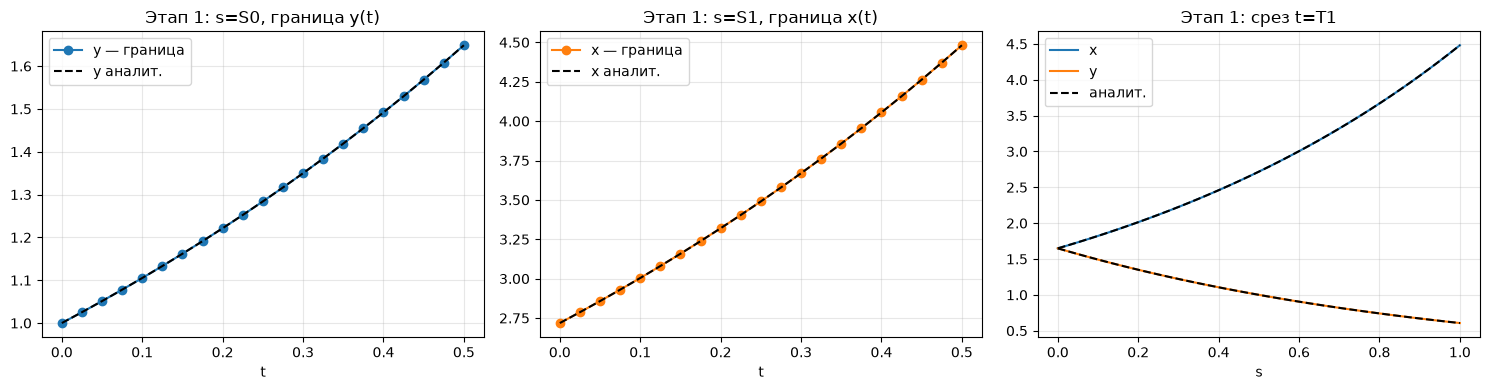

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

t, x, y = side_trace(mesh1, 'left')
ax[0].plot(t, y, 'o-', color='C0', label='y — граница')
ax[0].plot(t, y_an(S[0], t), 'k--', label='y аналит.')
ax[0].set_title('Этап 1: s=S0, граница y(t)')
ax[0].set_xlabel('t'); ax[0].legend(); ax[0].grid(alpha=0.3)

t, x, y = side_trace(mesh1, 'right')
ax[1].plot(t, x, 'o-', color='C1', label='x — граница')
ax[1].plot(t, x_an(S[1], t), 'k--', label='x аналит.')
ax[1].set_title('Этап 1: s=S1, граница x(t)')
ax[1].set_xlabel('t'); ax[1].legend(); ax[1].grid(alpha=0.3)

s, x, y = final_slice(mesh1)
ax[2].plot(s, x, 'C0', label='x')
ax[2].plot(s, y, 'C1', label='y')
ax[2].plot(s, x_an(s, T[1]), 'k--')
ax[2].plot(s, y_an(s, T[1]), 'k--', label='аналит.')
ax[2].set_title('Этап 1: срез t=T1')
ax[2].set_xlabel('s'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Этап 2 — граница как ОДУ, сцеплённое с ДУЧП

Теперь границу задаёт `ODEBlock`: компонента живёт во времени по ОДУ
(`dy/dt = G21·x + G22·y` слева, `dx/dt = G11·x + G12·y` справа) и сцеплена с
`HypBlock` через общие узлы. Ниже — сравнение с монолитным `TrapezoidalSolver`.

In [4]:
sys2, mesh2, hyp2 = build_hyp_blocks(**KW, boundaries='ode')
sys2.solve()

# референс — старый монолитный решатель
sys_ref, mesh_ref, solver_ref = build_hyp_system(**KW)
solver_ref.solve_forward(mesh_ref)

s_b, x_b, y_b = final_slice(mesh2)
s_r, x_r, y_r = final_slice(mesh_ref)
print('max|Δx| ODEBlock vs монолит:', np.max(np.abs(x_b - x_r)))
print('max|Δy| ODEBlock vs монолит:', np.max(np.abs(y_b - y_r)))
print('max|err| x vs аналит.:', np.max(np.abs(x_b - x_an(s_b, T[1]))))
print('max|err| y vs аналит.:', np.max(np.abs(y_b - y_an(s_b, T[1]))))

max|Δx| ODEBlock vs монолит: 0.0
max|Δy| ODEBlock vs монолит: 0.0
max|err| x vs аналит.: 0.00011672311567423321
max|err| y vs аналит.: 4.2940034565619456e-05


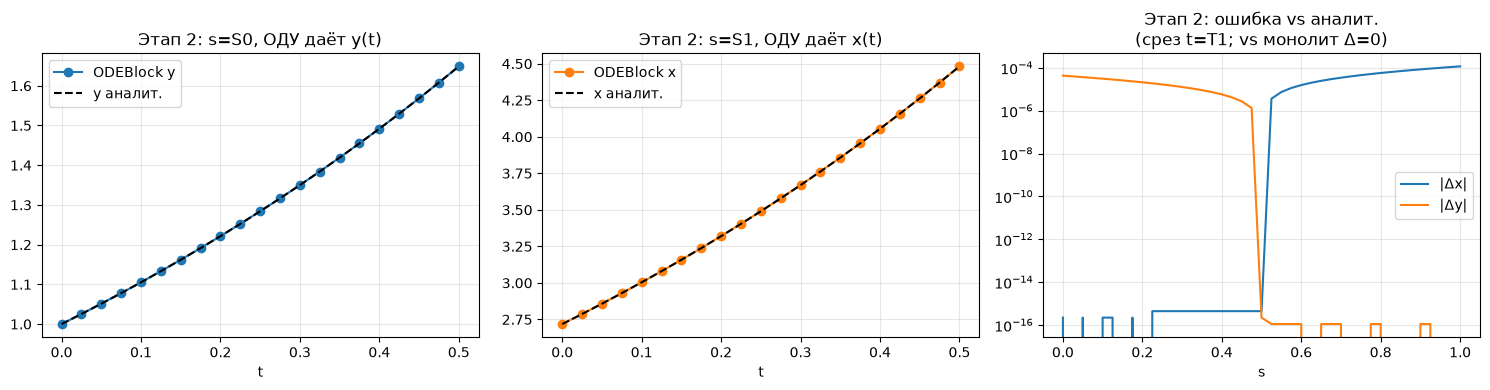

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

t, x, y = side_trace(mesh2, 'left')
ax[0].plot(t, y, 'o-', color='C0', label='ODEBlock y')
ax[0].plot(t, y_an(S[0], t), 'k--', label='y аналит.')
ax[0].set_title('Этап 2: s=S0, ОДУ даёт y(t)')
ax[0].set_xlabel('t'); ax[0].legend(); ax[0].grid(alpha=0.3)

t, x, y = side_trace(mesh2, 'right')
ax[1].plot(t, x, 'o-', color='C1', label='ODEBlock x')
ax[1].plot(t, x_an(S[1], t), 'k--', label='x аналит.')
ax[1].set_title('Этап 2: s=S1, ОДУ даёт x(t)')
ax[1].set_xlabel('t'); ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(s_b, np.abs(x_b - x_an(s_b, T[1])), 'C0', label='|Δx|')
ax[2].plot(s_b, np.abs(y_b - y_an(s_b, T[1])), 'C1', label='|Δy|')
ax[2].set_yscale('log')
ax[2].set_title('Этап 2: ошибка vs аналит.\n(срез t=T1; vs монолит Δ=0)')
ax[2].set_xlabel('s'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Этап 3 — одна переиспользуемая логика

Оба граничных блока используют один и тот же шаг `boundary_ode_step`
(левая и правая граница отличаются только аргументом `side`). Ниже мы
повторно проходим обе границы **одной функцией** и сравниваем с тем, что
сохранил `ODEBlock`.

In [6]:
import inspect

print('сигнатура:', inspect.signature(boundary_ode_step))
print('блоки и их стороны:',
      [(type(b).__name__, getattr(b, 'side', '-')) for b in sys2.blocks])


def replay_side(mesh, system, side):
    '''Повторно пройти границу одной функцией boundary_ode_step.'''
    s_const = mesh.S0 if side == 'left' else mesh.S1
    rows = []
    for i, j in mesh.order_center:
        node = mesh.center[(i, j)]
        if node.s != s_const:
            continue
        if side == 'left':
            char = mesh.get_center_node_right(i, j)
            prev = mesh.get_s0_node_left(i, j)
        else:
            char = mesh.get_center_node_left(i, j)
            prev = mesh.get_s1_node_right(i, j)
        val = boundary_ode_step(system, node.point,
                                prev.point, prev['X'],
                                char.point, char['X'], side)
        rows.append((node.t, val, node['X']))
    rows.sort(key=lambda r: r[0])
    t = np.array([r[0] for r in rows])
    v = np.array([r[1] for r in rows])
    stored = np.array([r[2] for r in rows])
    return t, v, stored


for side in ('left', 'right'):
    t, v, stored = replay_side(mesh2, sys2, side)
    print(f'{side:5s}: max|replay - ODEBlock| = {np.max(np.abs(v - stored)):.2e}')

сигнатура: (system: 'System', point: 'Point', prev_point: 'Point', prev_state: 'State', char_point: 'Point', char_state: 'State', side: 'str') -> 'State'
блоки и их стороны: [('HypBlock', '-'), ('ODEBlock', 'left'), ('ODEBlock', 'right')]
left : max|replay - ODEBlock| = 2.22e-16
right: max|replay - ODEBlock| = 0.00e+00


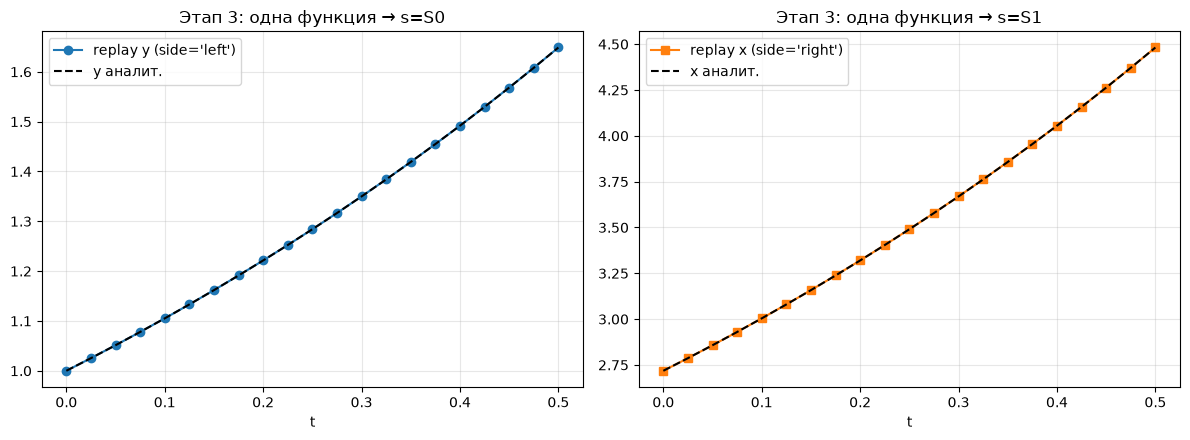

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

t, v, _ = replay_side(mesh2, sys2, 'left')
ax[0].plot(t, v[:, 1], 'o-', color='C0', label="replay y (side='left')")
ax[0].plot(t, y_an(S[0], t), 'k--', label='y аналит.')
ax[0].set_title('Этап 3: одна функция → s=S0')
ax[0].set_xlabel('t'); ax[0].legend(); ax[0].grid(alpha=0.3)

t, v, _ = replay_side(mesh2, sys2, 'right')
ax[1].plot(t, v[:, 0], 's-', color='C1', label="replay x (side='right')")
ax[1].plot(t, x_an(S[1], t), 'k--', label='x аналит.')
ax[1].set_title('Этап 3: одна функция → s=S1')
ax[1].set_xlabel('t'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Итог

* **Этап 1** — `PlainBoundaryBlock`: граница задана значением, вторая
  компонента идёт по характеристике (`boundary_plain_step`).
* **Этап 2** — `ODEBlock`: граница задана ОДУ, сцепленным с ДУЧП; результат
  совпадает с монолитным `TrapezoidalSolver`.
* **Этап 3** — оба блока используют один шаг `boundary_ode_step`; левая и
  правая граница — один и тот же код с разным `side`.